In [147]:
import gtsam
import numpy as np
from spatialmath.base import *
from spatialmath import SE2
import matplotlib.pyplot as plt


prior_noise    = gtsam.noiseModel.Diagonal.Sigmas(np.array([1e-1, 1e-1, 1e-1]))
odom_noise     = gtsam.noiseModel.Diagonal.Sigmas(np.array([0.05, 0.05, 0.1]))
loop_noise     = gtsam.noiseModel.Diagonal.Sigmas(np.array([0.01, 0.01, 0.02]))

odometry = np.array([
    [2.0, 0.0, 0.0],
    [2.0, 0.0, 0.0],
    [0.0, 2.0, np.deg2rad(90)],
    [0.0, 2.0, np.deg2rad(90)],
    [0.0, 2.0, np.deg2rad(90)],
    [2.0, 0.0, 0.0],
    [0.0, -2.0, np.deg2rad(-90)],
    [0.0, -2.0, np.deg2rad(-90)],
])

noised_odometry = odometry + np.random.multivariate_normal(
    mean=np.zeros(3),
    cov=np.diag([0.05, 0.05, 0.05]),
    size=odometry.shape[0]
)

odometry_SE2 = [SE2(p) for p in odometry]
noised_odometry_SE2 = [SE2(p) for p in noised_odometry]

poses = [odometry_SE2[0]]
noised_poses = [noised_odometry_SE2[0]]

for i in range(1, len(odometry_SE2)):
    poses.append(poses[i-1] * odometry_SE2[i])
    noised_poses.append(noised_poses[i-1] * noised_odometry_SE2[i])

def extract_result(result):
    poses = []
    for i in range(result.size()):
        pose = result.atPose2(i)
        poses.append(SE2(pose.x(), pose.y(), pose.theta()))
    return poses

def extract_positions(SE2_array):
    return np.array([pose.t for pose in SE2_array])

def compute_hessian(graph, result):
    gauss_graph = graph.linearize(result)
    H, b = gauss_graph.hessian()
    # convert to numpy
    return np.array(H), np.array(b)

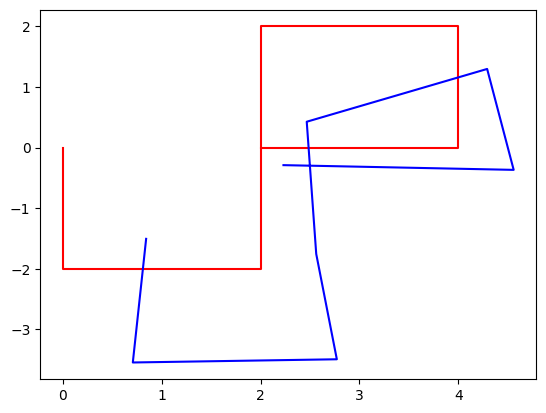

In [148]:
positions = extract_positions(poses)
noised_positions = extract_positions(noised_poses)

plt.plot(positions[:, 0], positions[:, 1], 'r-', label='ground truth')
plt.plot(noised_positions[:, 0], noised_positions[:, 1], 'b-', label='noisy odometry')

plt.show()

In [149]:
graph = gtsam.NonlinearFactorGraph()
initial = gtsam.Values()

prev = gtsam.Pose2(0.0, 0.0, 0.0)
graph.add(gtsam.PriorFactorPose2(0, prev, prior_noise))
initial.insert(0, prev)

for i in range(len(noised_odometry)):
    gtsam_odom = gtsam.Pose2(*noised_odometry[i])
    graph.add(gtsam.BetweenFactorPose2(i, i+1, gtsam_odom, odom_noise))
    initial.insert(i + 1, prev * gtsam_odom)
    
    prev = prev * gtsam_odom

optimizer = gtsam.LevenbergMarquardtOptimizer(graph, initial)
result1 = optimizer.optimize()
poses1 = extract_result(result1)
positions1 = extract_positions(poses1)
H1, b1 = compute_hessian(graph, result1)

In [150]:
graph = gtsam.NonlinearFactorGraph()
initial = gtsam.Values()

prev = gtsam.Pose2(0.0, 0.0, 0.0)
graph.add(gtsam.PriorFactorPose2(0, prev, prior_noise))
initial.insert(0, prev)

for i in range(len(noised_odometry)):
    gtsam_odom = gtsam.Pose2(*noised_odometry[i])
    graph.add(gtsam.BetweenFactorPose2(i, i+1, gtsam_odom, odom_noise))
    initial.insert(i + 1, prev * gtsam_odom)
    
    prev = prev * gtsam_odom

graph.add(gtsam.BetweenFactorPose2(1, 5, gtsam.Pose2(0, 0, np.deg2rad(-90)), loop_noise))

optimizer = gtsam.LevenbergMarquardtOptimizer(graph, initial)
result2 = optimizer.optimize()
poses2 = extract_result(result2)
positions2 = extract_positions(poses2)
H2, b2 = compute_hessian(graph, result2)

In [151]:
graph = gtsam.NonlinearFactorGraph()
initial = gtsam.Values()

prev = gtsam.Pose2(0.0, 0.0, 0.0)
graph.add(gtsam.PriorFactorPose2(0, prev, prior_noise))
initial.insert(0, prev)

for i in range(len(noised_odometry)):
    gtsam_odom = gtsam.Pose2(*noised_odometry[i])
    graph.add(gtsam.BetweenFactorPose2(i, i+1, gtsam_odom, odom_noise))
    initial.insert(i + 1, prev * gtsam_odom)
    
    prev = prev * gtsam_odom

graph.add(gtsam.BetweenFactorPose2(1, 5, gtsam.Pose2(0, 0, np.deg2rad(-90)), loop_noise))
graph.add(gtsam.BetweenFactorPose2(0, 8, gtsam.Pose2(0, 0, np.deg2rad(90)), loop_noise))

optimizer = gtsam.LevenbergMarquardtOptimizer(graph, initial)
result3 = optimizer.optimize()
poses3 = extract_result(result2)
positions3 = extract_positions(poses2)
H3, b3 = compute_hessian(graph, result2)

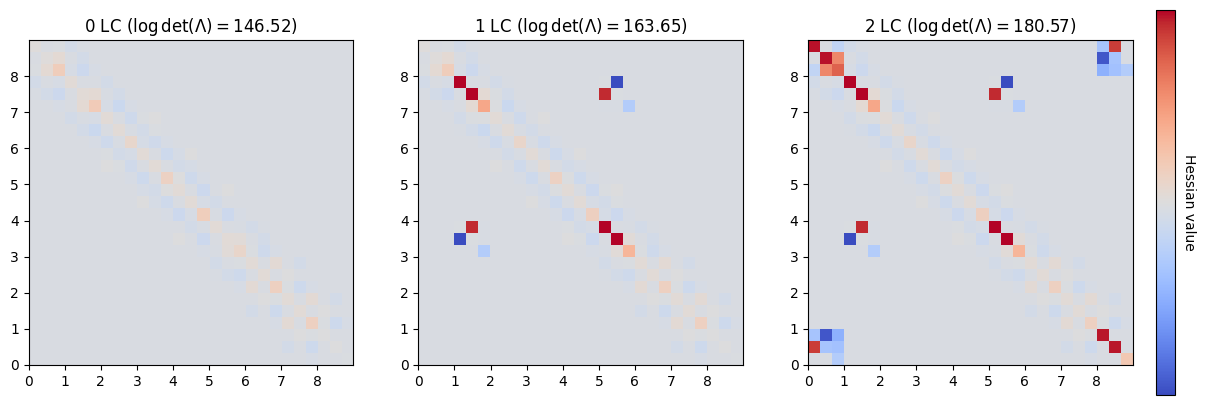

In [156]:
def plot_hessians(hessians):    
    # Compute global min/max for nonzero entries
    nonzeros = np.hstack([H[H != 0].flatten() for H in hessians])
    vmin, vmax = nonzeros.min(), nonzeros.max()
    extent = (0, len(hessians[0]), 0, len(hessians[0]))
    
    num_ticks = len(hessians[0]) // 3
    tick_spacing = 3
    
    tick_locs = np.arange(0, num_ticks * tick_spacing, tick_spacing)
    tick_labels = np.arange(num_ticks)
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    for i, (ax, H) in enumerate(zip(axes, hessians)):
        # H_masked = np.ma.masked_where(H == 0, H)
        im = ax.imshow(H, origin='upper', interpolation='none', vmin=vmin, vmax=vmax, zorder=2,
                       extent=extent, cmap='coolwarm')
        
        # Compute log-determinant
        _, logdet = np.linalg.slogdet(H)
        ax.set_title(rf"{i} LC ($\log\det(\Lambda) = {logdet:.2f}$)")
        ax.grid(True, zorder=1)
        ax.set_xticks(tick_locs)
        ax.set_yticks(tick_locs)
        ax.set_xticklabels(tick_labels)
        ax.set_yticklabels(tick_labels)

    
    # Single shared colorbar without ticks
    cbar = fig.colorbar(im, ax=axes, orientation='vertical', fraction=0.03, pad=0.02)
    cbar.ax.set_yticks([])
    cbar.ax.set_ylabel('Hessian value', rotation=270, labelpad=15)
    
    plt.savefig('hessians.png', dpi=300)
    plt.show()

plot_hessians(hessians=[
    H1,
    H2,
    H3
])